In [15]:
import glob
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
from scipy.stats import f_oneway
import numpy as np

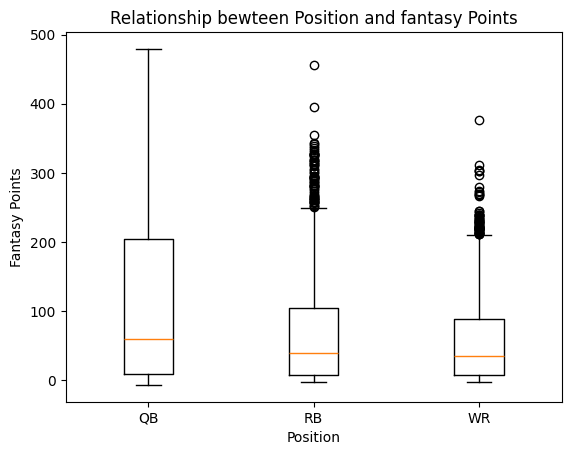

1.1064889293564035e-100


In [11]:
conn = sqlite3.connect(":memory:")
files = glob.glob("player_stats/*.csv")

for file in files:
    df = pd.read_csv(file)
    year = file.split("_")[-1].split(".")[0]
    df.to_sql(f"stats_{year}", conn, index=False, if_exists="replace")

years = sorted([file.split("_")[-1].split(".")[0] for file in files])

cols_to_drop = ["special_teams_tds", "headshot_url", "position_group"]

# get columns from one table (they should match across years)
first_year = years[0]
cols = pd.read_sql(f"PRAGMA table_info(stats_{first_year});", conn)
cols = [c[1] for c in cols.values]

keep_cols = [c for c in cols if c not in cols_to_drop]

query = " UNION ALL ".join([
    f"SELECT {', '.join(keep_cols)} FROM stats_{year}"
    for year in years
])

final_query = f"""
CREATE TABLE all_players_cleaned AS
{query}
"""
conn.execute(final_query)
all_players_cleaned = pd.read_sql("SELECT * FROM all_players_cleaned", conn)

position_group = all_players_cleaned.groupby("position")
qb_df = position_group.get_group("QB")
rb_df = position_group.get_group("RB")
wr_df = position_group.get_group("WR")

fig, ax = plt.subplots()
ax.boxplot((qb_df['fantasy_points'],rb_df['fantasy_points'],wr_df['fantasy_points']),tick_labels =("QB","RB","WR"))
plt.title("Relationship bewteen Position and fantasy Points")
plt.xlabel("Position")
plt.ylabel("Fantasy Points")
plt.show()
f_statistic, p_value = f_oneway(qb_df['fantasy_points'],rb_df['fantasy_points'],wr_df['fantasy_points'] )
print(p_value)

One conclusion we have made is that there is a statistically significant difference in fantasy points between the positions QB, RB, and WR with p = 1 x 10^-100.

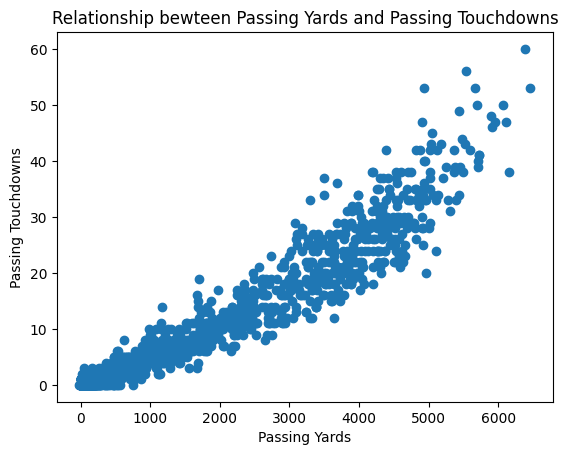

0.9749123735082296


In [17]:
fig, ax = plt.subplots()

ax.scatter(all_players_cleaned['passing_yards'], all_players_cleaned['passing_tds'])
plt.title("Relationship bewteen Passing Yards and Passing Touchdowns")
plt.xlabel("Passing Yards")
plt.ylabel("Passing Touchdowns")
plt.show()
corr_coef = np.corrcoef(all_players_cleaned['passing_yards'], all_players_cleaned['passing_tds'])[0,1]
print(corr_coef)

A second conclusion we have made based on the above scatter plot is that there is a positive correlation between passing touchdowns and passing yards. The correlation coefficient is 0.975, which is very close to 1 which indicitates a strong positive correlation.

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive
